In [4]:
import pandas as pd
import csv
import re

file_path = "engaged_sessions.csv"

# ---------------------------
# 1. Llegir el CSV de manera robusta
# ---------------------------
# Ignorem:
# - línies buides
# - línies de comentari que comencen per '#'
# - files malformades (com la de "Grand total", que té una columna extra)

rows = []
header = None

with open(file_path, encoding="utf-8-sig", newline="") as f:
    reader = csv.reader(f)
    for row in reader:
        if not row:
            continue
        if row[0].startswith("#"):
            continue

        if header is None:
            header = row
            continue

        # Només ens quedem amb files ben formades, amb el mateix nombre de columnes que la capçalera
        if len(row) == len(header):
            rows.append(row)

df = pd.DataFrame(rows, columns=header)

# Renombrar la columna del títol per comoditat
df = df.rename(columns={"Page title and screen class": "title"})

# ---------------------------
# 2. Convertir columnes numèriques
# ---------------------------
num_cols = ["Engaged sessions", "Views per session", "Average session duration"]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Eliminar files sense títol vàlid
df["title"] = df["title"].astype(str).str.strip()
df = df[df["title"] != ""].copy()

# ---------------------------
# 3. Filtrar cançons individuals
# ---------------------------
# Heurística:
# Les pàgines de cançó solen tenir una estructura semblant a:
# "Nom cançó, de l'àlbum "Nom disc" (Artista) - Viasona"

title = df["title"]

is_song = (
    title.str.contains(r"de l['’]àlbum", case=False, na=False)
    & title.str.contains(r"\(.+\)", na=False)
    & title.str.contains(r"-\s*Viasona$", case=False, na=False)
)

# Excloem pàgines que probablement no són cançons
not_song = title.str.contains(
    r"tota la música|agenda|concerts|notícies|artistes|grups|discografia|"
    r"llistat|llista|cerca|home|inici|cançons en català|enviar lletra|"
    r"vídeos|videoclips|biografia|entrevista|especial",
    case=False,
    na=False
)

songs = df[is_song & ~not_song].copy()

# ---------------------------
# 4. Estadístiques
# ---------------------------
mean_stats = songs[num_cols].mean()
median_stats = songs[num_cols].median()

# ---------------------------
# 5. Resultats
# ---------------------------
print("====================================")
print("RESUM DEL FILTRAT")
print("====================================")
print(f"Total de files llegides: {len(df)}")
print(f"Cançons individuals detectades: {len(songs)}")

if len(df) > 0:
    print(f"Percentatge classificat com a cançó: {100 * len(songs) / len(df):.2f}%")

print()

print("====================================")
print("EXEMPLES DE CANÇONS DETECTADES")
print("====================================")
print(songs["title"].head(15).to_string(index=False))
print()

print("====================================")
print("MITJANES")
print("====================================")
print(f"Engaged sessions:         {mean_stats['Engaged sessions']:.2f}")
print(f"Views per session:        {mean_stats['Views per session']:.4f}")
print(f"Average session duration: {mean_stats['Average session duration']:.2f} segons")
print()

print("====================================")
print("MEDIANES")
print("====================================")
print(f"Engaged sessions:         {median_stats['Engaged sessions']:.2f}")
print(f"Views per session:        {median_stats['Views per session']:.4f}")
print(f"Average session duration: {median_stats['Average session duration']:.2f} segons")
print()

# ---------------------------
# 6. Extra útil: top 20 cançons per engaged sessions
# ---------------------------
top_songs = songs.sort_values("Engaged sessions", ascending=False)[
    ["title", "Engaged sessions", "Views per session", "Average session duration"]
].head(20)

print("====================================")
print("TOP 20 CANÇONS PER ENGAGED SESSIONS")
print("====================================")
print(top_songs.to_string(index=False))
print()

# ---------------------------
# 7. Extra útil: alguns exemples de pàgines excloses
# ---------------------------
excluded = df[~(is_song & ~not_song)].copy()

print("====================================")
print("EXEMPLES DE PÀGINES EXCLOSES")
print("====================================")
print(excluded["title"].head(15).to_string(index=False))

RESUM DEL FILTRAT
Total de files llegides: 99924
Cançons individuals detectades: 58015
Percentatge classificat com a cançó: 58.06%

EXEMPLES DE CANÇONS DETECTADES
Que tinguem sort, de l'àlbum "18 anys de cançon...
Compta amb mi, de l'àlbum "Som riu" (Txarango) ...
Bon dia, de l'àlbum "Bon dia" (Els Pets) - Viasona
Qualsevol nit pot sortir el sol, de l'àlbum "Qu...
Ítaca, de l'àlbum "Viatge a Ítaca" (Lluís Llach...
Un núvol blanc, de l'àlbum "Maremar" (Lluís Lla...
Fum, fum, fum, de l'àlbum "Escudella de Nadales...
Creure, de l'àlbum "Pel barri és comenta" (La L...
Abril 74, de l'àlbum "Viatge a Ítaca" (Lluís Ll...
D'un concert de la Mushkaa, de l'àlbum "Pel bar...
Enganyar-te, de l'àlbum "Enganyar-te" (La Ludwi...
Dos fills del destí, de l'àlbum "Pel barri és c...
Louisiana o els camps de cotó, de l'àlbum "Espè...
Llença't, de l'àlbum "Llença't" (Lax'n'Busto) -...
Quan tot s'enlaira, de l'àlbum "Benvinguts al l...

MITJANES
Engaged sessions:         3.68
Views per session:        1.060

np.int64(213363)

np.int64(162116)

Cançons amb ≥10 sessions: 8601

Mitjana ponderada views/session: 1.0848
Mediana ponderada views/session: 1.0656

Decils:
P0: 0.6667
P10: 0.9773
P20: 1.0000
P30: 1.0292
P40: 1.0476
P50: 1.0656
P60: 1.0858
P70: 1.1071
P80: 1.1429
P90: 1.2143
P100: 2.8889

% sessions ≤ 1.1 views/session: 66.69%
% sessions ≤ 1.2 views/session: 89.33%



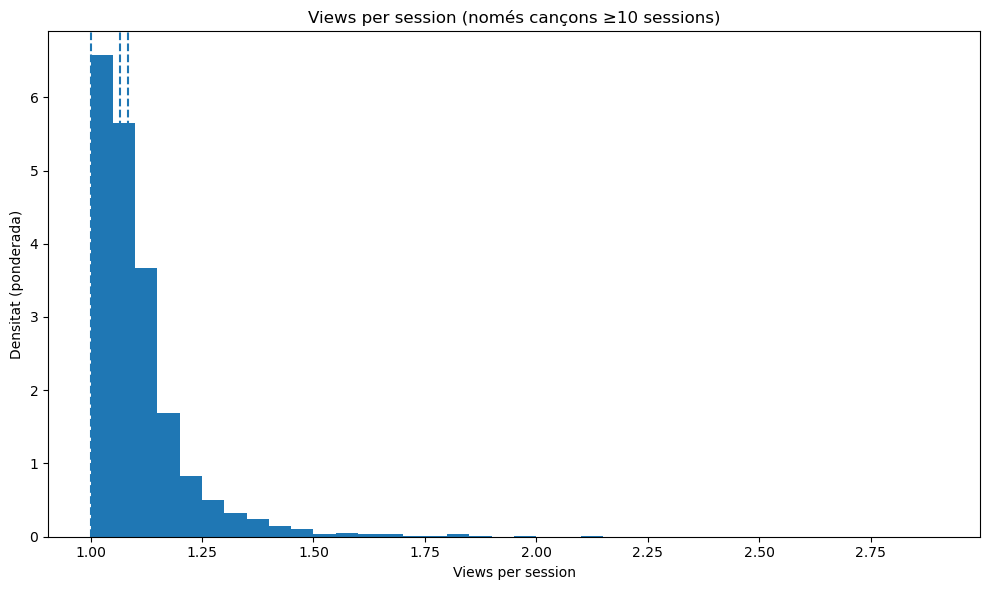

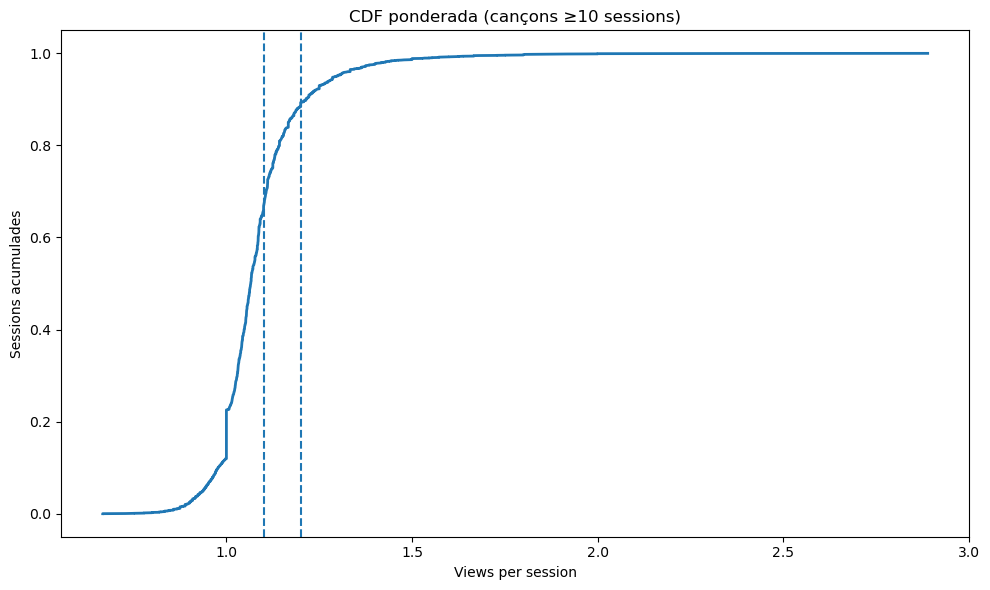

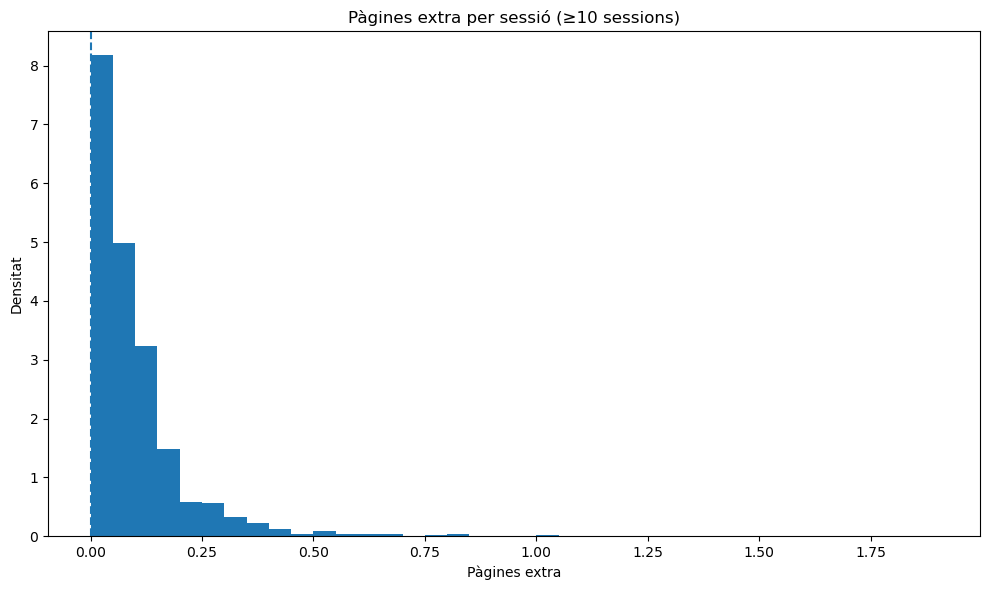

In [ ]:
import pandas as pd
import csv
import numpy as np
import matplotlib.pyplot as plt

file_path = "engaged_sessions.csv"

# ============================================================
# 1. LLEGIR CSV
# ============================================================
rows = []
header = None

with open(file_path, encoding="utf-8-sig", newline="") as f:
    reader = csv.reader(f)
    for row in reader:
        if not row:
            continue
        if row[0].startswith("#"):
            continue

        if header is None:
            header = row
            continue

        if len(row) == len(header):
            rows.append(row)

df = pd.DataFrame(rows, columns=header)
df = df.rename(columns={"Page title and screen class": "title"})

# ============================================================
# 2. NETEJA
# ============================================================
num_cols = ["Engaged sessions", "Views per session", "Average session duration"]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["title"] = df["title"].astype(str).str.strip()
df = df.dropna(subset=["title"] + num_cols)
df = df[df["title"] != ""]
df = df[df["Engaged sessions"] > 0]

# ============================================================
# 3. FILTRAR CANÇONS
# ============================================================
title = df["title"]

is_song = (
    title.str.contains(r"de l['’]àlbum", case=False, na=False)
    & title.str.contains(r"\(.+\)", na=False)
    & title.str.contains(r"-\s*Viasona$", case=False, na=False)
)

not_song = title.str.contains(
    r"tota la música|agenda|concerts|notícies|artistes|grups|discografia|"
    r"llistat|llista|cerca|home|inici|cançons en català|enviar lletra|"
    r"vídeos|videoclips|biografia|entrevista|especial",
    case=False,
    na=False
)

songs = df[is_song & ~not_song].copy()

# ============================================================
# 4. FILTRE IMPORTANT: ≥10 sessions
# ============================================================
display(songs["Engaged sessions"].sum())
songs = songs[songs["Engaged sessions"] >= 5].copy()

display(songs["Engaged sessions"].sum())
print(f"Cançons amb ≥10 sessions: {len(songs)}")
print()

# ============================================================
# 5. FUNCIONS PONDERADES
# ============================================================
def weighted_mean(values, weights):
    return np.sum(values * weights) / np.sum(weights)

def weighted_percentile(values, weights, percentile):
    order = np.argsort(values)
    values_sorted = values[order]
    weights_sorted = weights[order]

    cum_weights = np.cumsum(weights_sorted)
    cutoff = percentile / 100 * weights_sorted.sum()

    idx = np.searchsorted(cum_weights, cutoff, side="left")
    idx = min(idx, len(values_sorted) - 1)

    return values_sorted[idx]

# ============================================================
# 6. ESTADÍSTIQUES
# ============================================================
weights = songs["Engaged sessions"].to_numpy()
views = songs["Views per session"].to_numpy()
duration = songs["Average session duration"].to_numpy()

weighted_mean_views = weighted_mean(views, weights)
weighted_median_views = weighted_percentile(views, weights, 50)

# percentils
deciles = {p: weighted_percentile(views, weights, p) for p in range(0, 101, 10)}

# mètriques interpretables
share_leq_1_1 = weights[views <= 1.1].sum() / weights.sum()
share_leq_1_2 = weights[views <= 1.2].sum() / weights.sum()

print("Mitjana ponderada views/session:", round(weighted_mean_views, 4))
print("Mediana ponderada views/session:", round(weighted_median_views, 4))
print()

print("Decils:")
for p in deciles:
    print(f"P{p}: {deciles[p]:.4f}")

print()
print(f"% sessions ≤ 1.1 views/session: {100*share_leq_1_1:.2f}%")
print(f"% sessions ≤ 1.2 views/session: {100*share_leq_1_2:.2f}%")
print()

# ============================================================
# 7. GRÀFICS
# ============================================================

# ---------- HISTOGRAMA ----------
plt.figure(figsize=(10, 6))

bins = np.arange(1.0, max(2.0, views.max()+0.05), 0.05)

plt.hist(
    views,
    bins=bins,
    weights=weights,
    density=True
)

plt.axvline(1.0, linestyle="--")
plt.axvline(weighted_mean_views, linestyle="--")
plt.axvline(weighted_median_views, linestyle="--")

plt.title("Views per session (només cançons ≥10 sessions)")
plt.xlabel("Views per session")
plt.ylabel("Densitat (ponderada)")
plt.tight_layout()
plt.show()

# ---------- CDF ----------
tmp = songs[["Views per session", "Engaged sessions"]].sort_values("Views per session").copy()
tmp["cum"] = tmp["Engaged sessions"].cumsum() / tmp["Engaged sessions"].sum()

plt.figure(figsize=(10, 6))
plt.plot(tmp["Views per session"], tmp["cum"], linewidth=2)

plt.axvline(1.1, linestyle="--")
plt.axvline(1.2, linestyle="--")

plt.title("CDF ponderada (cançons ≥10 sessions)")
plt.xlabel("Views per session")
plt.ylabel("Sessions acumulades")
plt.tight_layout()
plt.show()

# ---------- EXTRA PAGES ----------
extra = (songs["Views per session"] - 1).clip(lower=0)

plt.figure(figsize=(10, 6))
plt.hist(
    extra,
    bins=np.arange(0, max(1.0, extra.max()+0.05), 0.05),
    weights=weights,
    density=True
)

plt.axvline(0.0, linestyle="--")

plt.title("Pàgines extra per sessió (≥5 sessions)")
plt.xlabel("Pàgines extra")
plt.ylabel("Densitat")
plt.tight_layout()
plt.show()